In [3]:
total_batches = tf.data.experimental.cardinality(validation_test_dataset).numpy()

test_size = total_batches // 2

test_dataset = validation_test_dataset.take(test_size)
validation_dataset = validation_test_dataset.skip(test_size)

print("Validation batches:", 
      tf.data.experimental.cardinality(validation_dataset).numpy())

print("Test batches:", 
      tf.data.experimental.cardinality(test_dataset).numpy())

Validation batches: 255
Test batches: 255


In [2]:
DATASET_PATH = "../dataset/color"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.30,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

validation_test_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.30,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

print("Train batches:", tf.data.experimental.cardinality(train_dataset).numpy())
print("Validation + Test batches:", tf.data.experimental.cardinality(validation_test_dataset).numpy())

Found 54305 files belonging to 38 classes.
Using 38014 files for training.
Found 54305 files belonging to 38 classes.
Using 16291 files for validation.
Train batches: 1188
Validation + Test batches: 510


In [1]:
import tensorflow as tf
import os

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [6]:
DATASET_PATH = "../dataset/color"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.30,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

validation_test_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.30,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

print("Train batches:",
      tf.data.experimental.cardinality(train_dataset).numpy())

print("Validation + Test batches:",
      tf.data.experimental.cardinality(validation_test_dataset).numpy())

Found 54305 files belonging to 38 classes.
Using 38014 files for training.
Found 54305 files belonging to 38 classes.
Using 16291 files for validation.
Train batches: 1188
Validation + Test batches: 510


In [7]:
total_batches = tf.data.experimental.cardinality(
    validation_test_dataset
).numpy()

test_size = total_batches // 2

test_dataset = validation_test_dataset.take(test_size)

validation_dataset = validation_test_dataset.skip(test_size)

print(
    "Validation batches:",
    tf.data.experimental.cardinality(validation_dataset).numpy()
)

print(
    "Test batches:",
    tf.data.experimental.cardinality(test_dataset).numpy()
)

Validation batches: 255
Test batches: 255


In [8]:
class_names = train_dataset.class_names

print("Number of classes:", len(class_names))

print("\nClasses:")

for i, class_name in enumerate(class_names):
    print(i, ":", class_name)

Number of classes: 38

Classes:
0 : Apple___Apple_scab
1 : Apple___Black_rot
2 : Apple___Cedar_apple_rust
3 : Apple___healthy
4 : Blueberry___healthy
5 : Cherry_(including_sour)___Powdery_mildew
6 : Cherry_(including_sour)___healthy
7 : Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
8 : Corn_(maize)___Common_rust_
9 : Corn_(maize)___Northern_Leaf_Blight
10 : Corn_(maize)___healthy
11 : Grape___Black_rot
12 : Grape___Esca_(Black_Measles)
13 : Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
14 : Grape___healthy
15 : Orange___Haunglongbing_(Citrus_greening)
16 : Peach___Bacterial_spot
17 : Peach___healthy
18 : Pepper,_bell___Bacterial_spot
19 : Pepper,_bell___healthy
20 : Potato___Early_blight
21 : Potato___Late_blight
22 : Potato___healthy
23 : Raspberry___healthy
24 : Soybean___healthy
25 : Squash___Powdery_mildew
26 : Strawberry___Leaf_scorch
27 : Strawberry___healthy
28 : Tomato___Bacterial_spot
29 : Tomato___Early_blight
30 : Tomato___Late_blight
31 : Tomato___Leaf_Mold
32 : Tomato___

In [ ]:
for images, labels in train_dataset.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)

In [9]:
from tensorflow.keras import layers

# Normalization
normalization_layer = layers.Rescaling(1./255)

# Data augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
])

print("Normalization and augmentation created successfully!")

Normalization and augmentation created successfully!


In [10]:
for images, labels in train_dataset.take(1):

    print("Before normalization:")
    print("Minimum pixel value:", tf.reduce_min(images).numpy())
    print("Maximum pixel value:", tf.reduce_max(images).numpy())

    normalized_images = normalization_layer(images)

    print("\nAfter normalization:")
    print("Minimum pixel value:", tf.reduce_min(normalized_images).numpy())
    print("Maximum pixel value:", tf.reduce_max(normalized_images).numpy())

Before normalization:
Minimum pixel value: 0.0
Maximum pixel value: 254.43878

After normalization:
Minimum pixel value: 0.0
Maximum pixel value: 0.9977992


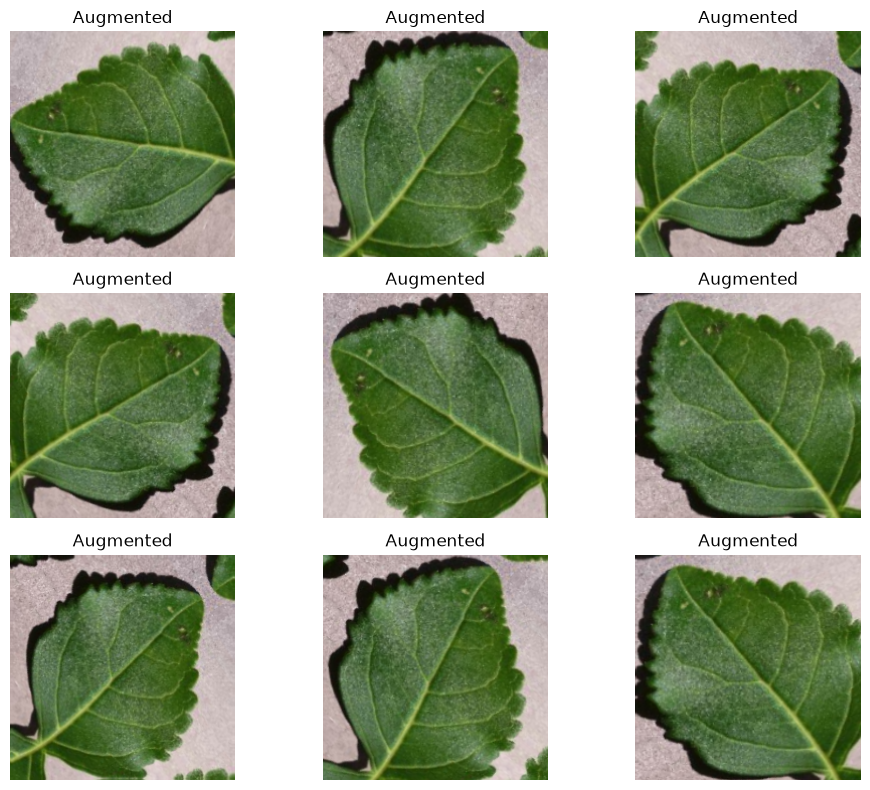

In [11]:
import matplotlib.pyplot as plt

for images, labels in train_dataset.take(1):

    original_image = images[0]

    plt.figure(figsize=(10, 8))

    for i in range(9):
        augmented_image = data_augmentation(
            tf.expand_dims(original_image, 0),
            training=True
        )

        plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_image[0].numpy().astype("uint8"))
        plt.axis("off")
        plt.title("Augmented")

    plt.tight_layout()
    plt.show()

In [12]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().shuffle(1000).prefetch(
    buffer_size=AUTOTUNE
)

validation_dataset = validation_dataset.cache().prefetch(
    buffer_size=AUTOTUNE
)

test_dataset = test_dataset.cache().prefetch(
    buffer_size=AUTOTUNE
)

print("Dataset pipeline optimized successfully!")

Dataset pipeline optimized successfully!
